In [ ]:
!pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.8 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.64.0 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.64.0 which is incompatible.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import random

from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import accuracy_score, f1_score
from tslearn.datasets import UCR_UEA_datasets

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

print("Seed fixed:", seed)

Seed fixed: 42


In [ ]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("Unique labels:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

X_train shape: (2459, 36, 6)
y_train shape: (2459,)
X_test shape: (2466, 36, 6)
y_test shape: (2466,)
Unique labels: ['15' '16' '42' '52' '53' '6' '62' '64' '65' '67' '88' '90' '92' '95']
Number of classes: 14


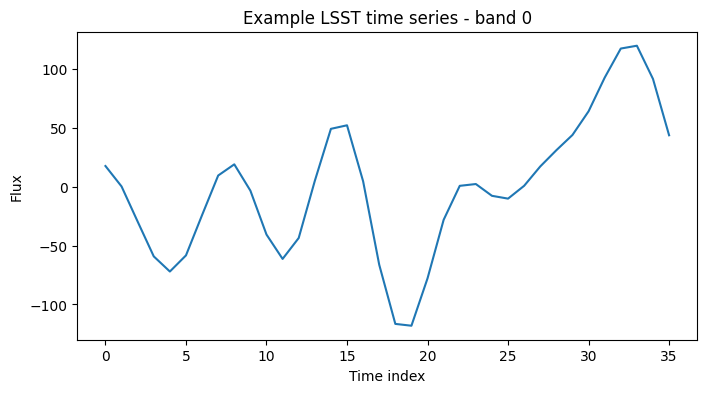

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(X_train[0, :, 0])
plt.title("Example LSST time series - band 0")
plt.xlabel("Time index")
plt.ylabel("Flux")
plt.show()

In [ ]:
unique_labels = np.unique(y_train)

label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_train = np.array([label_to_idx[y] for y in y_train])
y_test = np.array([label_to_idx[y] for y in y_test])

print("Mapping:", label_to_idx)
print("Mapped labels:", np.unique(y_train))

Mapping: {np.str_('15'): 0, np.str_('16'): 1, np.str_('42'): 2, np.str_('52'): 3, np.str_('53'): 4, np.str_('6'): 5, np.str_('62'): 6, np.str_('64'): 7, np.str_('65'): 8, np.str_('67'): 9, np.str_('88'): 10, np.str_('90'): 11, np.str_('92'): 12, np.str_('95'): 13}
Mapped labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]


In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape)
print(X_test.shape)

torch.Size([2459, 36, 6])
torch.Size([2466, 36, 6])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(X_train, y_train)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

test_dataset = TensorDataset(X_test, y_test)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 1967
Validation size: 492


In [ ]:
import torch.nn as nn

class LSTMClassifier(nn.Module):

    def __init__(self, input_dim=6, hidden_dim=64, num_classes=14):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):

        output, (h, c) = self.lstm(x)

        last_hidden = h[-1]

        out = self.fc(last_hidden)

        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMClassifier().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

LSTMClassifier(
  (lstm): LSTM(6, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=14, bias=True)
)


In [ ]:
num_epochs = 20

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    model.eval()

    val_preds = []
    val_true = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            val_preds.extend(preds)
            val_true.extend(y_batch.numpy())

    val_acc = accuracy_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds, average="macro")

    print(f"Epoch {epoch+1}/{num_epochs}  |  Train loss {train_loss:.3f}  |  Val acc {val_acc:.3f}  |  Val F1 {val_f1:.3f}")

Epoch 1/20  |  Train loss 77.280  |  Val acc 0.337  |  Val F1 0.069
Epoch 2/20  |  Train loss 65.134  |  Val acc 0.352  |  Val F1 0.070
Epoch 3/20  |  Train loss 59.896  |  Val acc 0.358  |  Val F1 0.077
Epoch 4/20  |  Train loss 57.429  |  Val acc 0.378  |  Val F1 0.103
Epoch 5/20  |  Train loss 54.961  |  Val acc 0.409  |  Val F1 0.132
Epoch 6/20  |  Train loss 51.924  |  Val acc 0.429  |  Val F1 0.156
Epoch 7/20  |  Train loss 49.278  |  Val acc 0.453  |  Val F1 0.177
Epoch 8/20  |  Train loss 46.700  |  Val acc 0.467  |  Val F1 0.177
Epoch 9/20  |  Train loss 45.119  |  Val acc 0.463  |  Val F1 0.190
Epoch 10/20  |  Train loss 43.188  |  Val acc 0.490  |  Val F1 0.217
Epoch 11/20  |  Train loss 41.550  |  Val acc 0.498  |  Val F1 0.224
Epoch 12/20  |  Train loss 40.612  |  Val acc 0.486  |  Val F1 0.223
Epoch 13/20  |  Train loss 39.111  |  Val acc 0.492  |  Val F1 0.238
Epoch 14/20  |  Train loss 37.817  |  Val acc 0.506  |  Val F1 0.240
Epoch 15/20  |  Train loss 37.544  |  Val a

In [ ]:
model.eval()

test_preds = []
test_true = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        test_preds.extend(preds)
        test_true.extend(y_batch.numpy())

test_acc = accuracy_score(test_true, test_preds)
test_f1 = f1_score(test_true, test_preds, average="macro")

print("Test accuracy:", test_acc)
print("Test macro F1:", test_f1)

Test accuracy: 0.5624493106244931
Test macro F1: 0.30921885659208775
